In [1]:
import os
import sys
sys.path.append("..")
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")
from scipy import stats

In [2]:
# Plot color
cols1 = sns.color_palette("Greys", 2)
cols2 = sns.color_palette("Oranges", 2)
cols3 = sns.color_palette("Blues", 2)

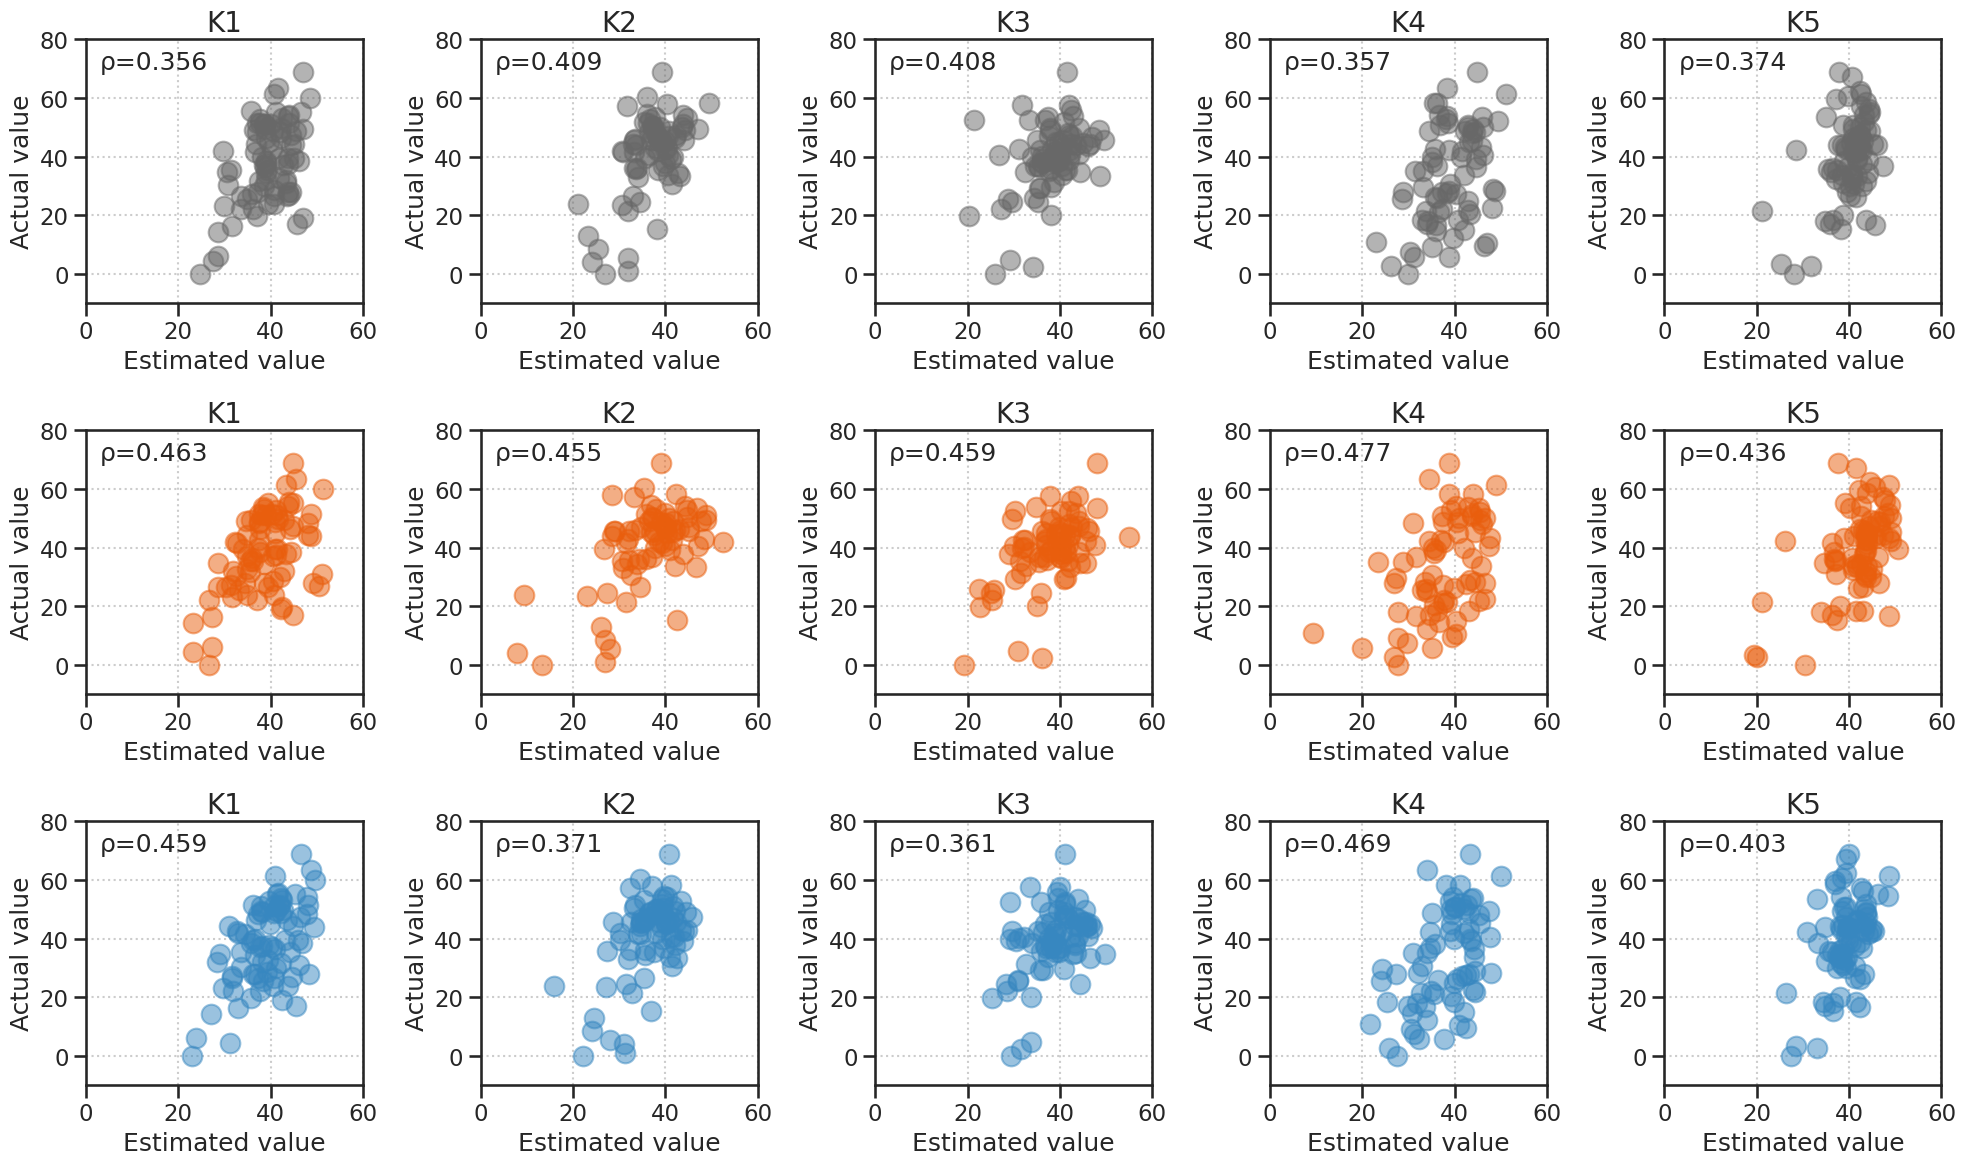

In [3]:
# Data path
pretrained_model_path = "../results/prediction/pretrained/esm2_t12_35M_UR50D/estimates/ridge/*.csv"
best_model1 = "esm2_35M_high_batch128_constant_warmup0.0_lr5e-6/epoch10"
best_model2 = "esm2_35M_low_batch128_constant_warmup0.0_lr5e-6/epoch5"
best_model1_path = f"../results/prediction/finetuned/{best_model1}/estimates/ridge/*.csv"
best_model2_path = f"../results/prediction/finetuned/{best_model2}/estimates/ridge/*.csv"


# Plot
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

nrow = 0
for i, file_path in enumerate(glob(pretrained_model_path)):
    df = pd.read_csv(file_path)
    rho = stats.spearmanr(df.estimate, df.actual).statistic
    axes[nrow, i].scatter(df.estimate, df.actual, s=200, alpha=0.5, color=cols1[1])
    axes[nrow, i].text(3, 70, f"ρ={rho:.3f}")
    axes[nrow, i].set_xlim(0, 60)
    axes[nrow, i].set_ylim(-10, 80)
    axes[nrow, i].set_xlabel("Estimated value")
    axes[nrow, i].set_ylabel("Actual value")
    axes[nrow, i].set_title(f"K{i+1}", fontsize=20)
    axes[nrow, i].grid(axis="both", linestyle="dotted")

nrow = 1
for i, file_path in enumerate(glob(best_model1_path)):
    df = pd.read_csv(file_path)
    rho = stats.spearmanr(df.estimate, df.actual).statistic
    axes[nrow, i].scatter(df.estimate, df.actual, s=200, alpha=0.5, color=cols2[1])
    axes[nrow, i].text(3, 70, f"ρ={rho:.3f}")
    axes[nrow, i].set_xlim(0, 60)
    axes[nrow, i].set_ylim(-10, 80)
    axes[nrow, i].set_xlabel("Estimated value")
    axes[nrow, i].set_ylabel("Actual value")
    axes[nrow, i].set_title(f"K{i+1}", fontsize=20)
    axes[nrow, i].grid(axis="both", linestyle="dotted")

nrow = 2
for i, file_path in enumerate(glob(best_model2_path)):
    df = pd.read_csv(file_path)
    rho = stats.spearmanr(df.estimate, df.actual).statistic
    axes[nrow, i].scatter(df.estimate, df.actual, s=200, alpha=0.5, color=cols3[1])
    axes[nrow, i].text(3, 70, f"ρ={rho:.3f}")
    axes[nrow, i].set_xlim(0, 60)
    axes[nrow, i].set_ylim(-10, 80)
    axes[nrow, i].set_xlabel("Estimated value")
    axes[nrow, i].set_ylabel("Actual value")
    axes[nrow, i].set_title(f"K{i+1}", fontsize=20)
    axes[nrow, i].grid(axis="both", linestyle="dotted")

fig.tight_layout()
fig.savefig("./figures/predcition_estimates_vs_actual.svg")